In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

Функция 
$$
    f(x,y) = I\{4-(x-10)^2-(y-5)^2\} + I\{9-(x-4)^2-(y-7)^2\} + I\{1-(x-6)^2-(y-3)^2\} + I\{4-(x-13)^2-(y-8)^2\}
$$

In [11]:
def f(x, y):
    circ1 = (4 - (x - 10)**2 - (y - 5)**2) >= 0
    circ2 = (9 - (x - 4)**2 - (y - 7)**2) >= 0
    circ3 = (1 - (x - 6)**2 - (y - 3)**2) >= 0
    circ4 = (4 - (x - 13)**2 - (y - 8)**2) >= 0
    return circ1.astype(int) + circ2.astype(int) + circ3.astype(int) + circ4.astype(int)

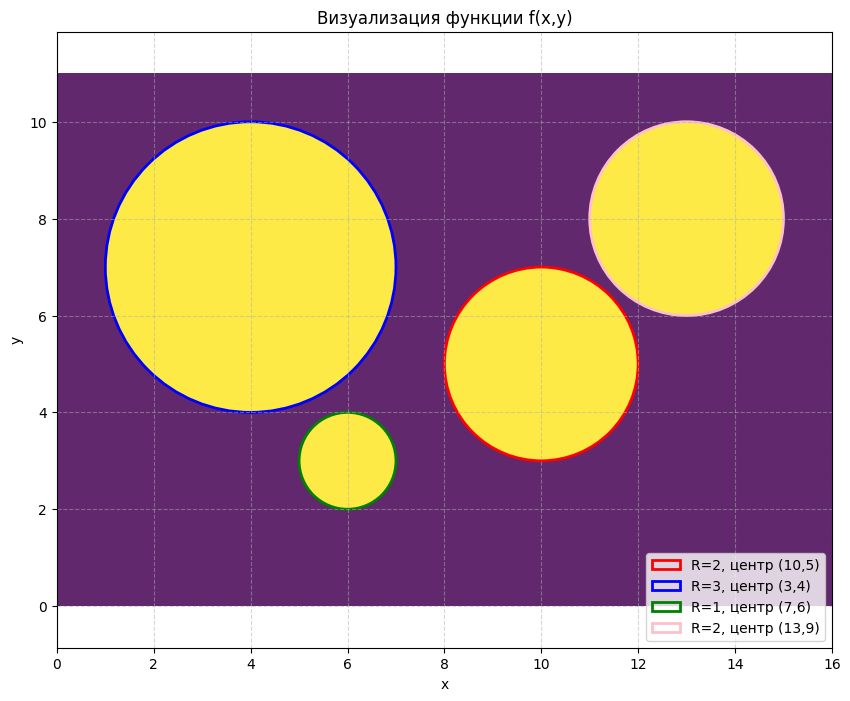

In [ ]:
# Параметры сетки
x_min, x_max = 0.0, 16.0
y_min, y_max = 0.0, 11.0
N = 1000  

# Создаём сетку
x = np.linspace(x_min, x_max, N)
y = np.linspace(y_min, y_max, N)
X, Y = np.meshgrid(x, y)

# Вычисляем значения функции на сетке
Z = f(X, Y)

# Построение изображения
plt.figure(figsize=(10, 8))
plt.imshow(Z, extent=[x_min, x_max, y_min, y_max], origin='lower',
           cmap='viridis', alpha=0.85)

# Добавляем границы кругов для наглядности
circle1 = Circle((10, 5), 2, fill=False, edgecolor='red', linewidth=2, label='R=2, центр (10,5)')
circle2 = Circle((4, 7), 3, fill=False, edgecolor='blue', linewidth=2, label='R=3, центр (3,4)')
circle3 = Circle((6, 3), 1, fill=False, edgecolor='green', linewidth=2, label='R=1, центр (7,6)')
circle4 = Circle((13, 8), 2, fill=False, edgecolor='pink', linewidth=2, label='R=2, центр (13,9)')

ax = plt.gca()
ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)
ax.add_patch(circle4)

# Оформление
plt.xlabel('x')
plt.ylabel('y')
plt.title('Визуализация функции f(x,y)')
plt.legend(loc='lower right')
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Прямая задача
$$
u^{i+1}_{j,k}=\frac{\tau^2}{h^2}(u^{i}_{j+1,k} + u^{i}_{j-1,k}+ u^{i}_{j,k+1} + u^{i}_{j,k-1} - 4u^{i}_{j,k}) + 2u^{i}_{j,k} - u^{i-1}_{j,k} \\
$$
Начальные условия:
$$
u^{0}_{j,k}= u^{1}_{j,k} = f_{j,k} 
$$
Значения для граничных узлов:
$$
u_x(0, y_k, t_i)= \frac{u(h, y_k, t_i)-u(-h, y_k, t_i)}{2h}=0  \\
u_x(l, y_k, t_i)= \frac{u(l+h, y_k, t_i)-u(l-h, y_k, t_i)}{2h}=0  \\
u_y(x_j, 0, t_i)= \frac{u(x_j,h, t_i)-u(x_j,-h, t_i)}{2h}=0 \\
u_y(x_j, l, t_i)= \frac{u(x_j,l+h, t_i)-u(x_j,l-h, t_i)}{2h}=0  \\
$$

In [23]:
def solve_forward_problem(f_vals, T_steps, h, tau):
    """
    Решает прямую задачу фотоакустики с условиями Неймана на границах.
    """
    nx, ny = f_vals.shape
    u = np.zeros((T_steps, nx, ny))

    # Начальные условия
    u[0] = f_vals.copy()
    u[1] = f_vals.copy()

    # Расчет прямой задачи (явная схема)
    for i in range(1, T_steps - 1):
        # mode='reflect' задает однородные условия Неймана
        u_pad = np.pad(u[i], 1, mode='reflect')
        
        # Пятиточечный шаблон Лапласиана
        L = (u_pad[2:, 1:-1] + u_pad[:-2, 1:-1] + u_pad[1:-1, 2:] + u_pad[1:-1, :-2] - 4 * u_pad[1:-1, 1:-1]) / h**2
        
        # Шаг по времени
        u[i+1] = tau**2 * L + 2 * u[i] - u[i-1]

    return u

# Обратная задача
$u^f$ - решение прямой задачи
$$
v^{i-1}_{j,k}=\frac{\tau^2}{h^2}(v^{i}_{j+1,k} + v^{i}_{j-1,k}+ v^{i}_{j,k+1} + v^{i}_{j,k-1} - 4v^{i}_{j,k}) + 2v^{i}_{j,k} - v^{i+1}_{j,k} \\
$$
Начальные условия:
$$
v^{T}_{j,k}= v^{T-\tau}_{j,k} = 0 
$$
Значения для граничных узлов:
$$
v|_{\partial \Omega *[0,T]} = u^f
$$

In [40]:
def solve_inverse_problem(u, T_steps, h, tau):
    """
    Решает обратную задачу методом обращения времени 
    с граничными условиями Дирихле, взятыми из прямой задачи.
    """
    nx, ny = u.shape[1], u.shape[2]
    v = np.zeros((T_steps, nx, ny))

    # "Неправильные" начальные условия для обратного времени
    v[-1] = 0
    v[-2] = 0

    # Обратный ход по времени
    for i in range(T_steps - 2, 0, -1):
        # mode='constant' дает нули на расширенных краях для внутреннего расчета
        v_pad = np.pad(v[i], 1, mode='constant')
        L = (v_pad[2:, 1:-1] + v_pad[:-2, 1:-1] + v_pad[1:-1, 2:] + v_pad[1:-1, :-2] - 4 * v_pad[1:-1, 1:-1]) / h**2
        
        v[i-1] = tau**2 * L + 2 * v[i] - v[i+1]
        
        # Граничные условия Дирихле (записываем данные, "измеренные" датчиками)
        v[i-1, 0, :] = u[i-1, 0, :]
        v[i-1, -1, :] = u[i-1, -1, :]
        v[i-1, :, 0] = u[i-1, :, 0]
        v[i-1, :, -1] = u[i-1, :, -1]

    return v

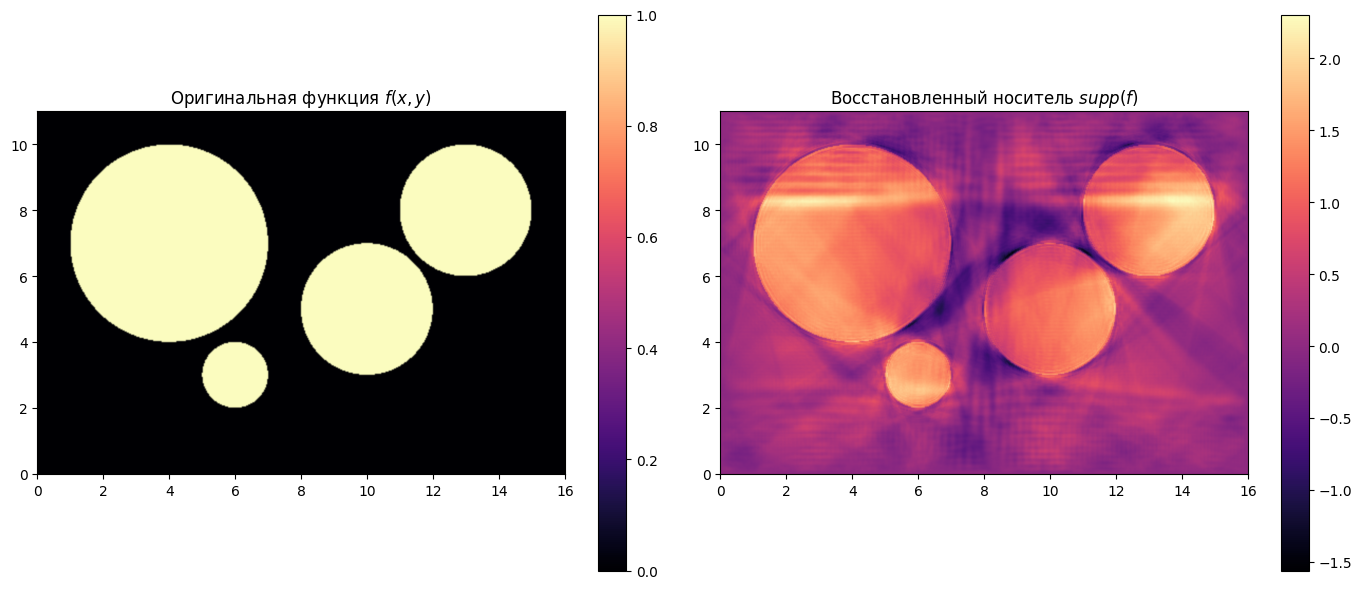

In [43]:
L_x, L_y = 16, 11

N = 500
h = L_x / (N - 1)
tau = h / 2.0  # Условие устойчивости Куранта (CFL)
T_total = 25.0# Чтобы волна дошла до углов, нужно T_total > sqrt(16^2 + 11^2) / speed
T_steps = int(T_total / tau)

# Создание сетки
x_arr = np.linspace(0, L_x, N)
y_arr = np.linspace(0, L_y, int(L_y/h) + 1)
X, Y = np.meshgrid(x_arr, y_arr, indexing='ij')

f_vals = f(X, Y)

# Запуск функций
u_forward = solve_forward_problem(f_vals, T_steps, h, tau)
v_inverse = solve_inverse_problem(u_forward, T_steps, h, tau)

# Визуализация с интерполяцией для идеальной плавности
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Оригинал
im1 = axes[0].imshow(f_vals.T, extent=[0, 16, 0, 11], origin='lower', 
                        cmap='magma', interpolation='bicubic')
axes[0].set_title('Оригинальная функция $f(x, y)$')
fig.colorbar(im1, ax=axes[0])

# Восстановление (v_inverse[0] — это момент t=0 в обратном времени)
im2 = axes[1].imshow(v_inverse[0].T, extent=[0, 16, 0, 11], origin='lower', 
                        cmap='magma', interpolation='bicubic')
axes[1].set_title('Восстановленный носитель $supp(f)$')
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()